#### Importing packages

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

#### Root directory/folder for the current project

Python by default does not know the location of the root directory/folder `Example`.
Let us copy the path from the file explorer to specify the root directory for our current project.
Here you need to change the path according to your computer and the location of your root directory.

In [12]:
# String -> type of object for text data
# One can use single quotes or double quotes, in general it does not make a difference
ROOT = r'C:\Users\PC_DS_ECON_5\Desktop\Example' 
ROOT = r"C:\Users\PC_DS_ECON_5\Desktop\Example"
print(ROOT)

C:\Users\PC_DS_ECON_5\Desktop\Example


The `r` before the quotation marks makes the `string` a `raw string`, such that the backslashes `\` are interpreted literally. For example: without `r`, `\n` would be interpreted as new line.

In [13]:
ROOT

'C:\\Users\\PC_DS_ECON_5\\Desktop\\Example'

In [14]:
# printing the type of object: should be str (String)
print('type of the object:', type(ROOT))

type of the object: <class 'str'>


#### Loading data

Let us use the `read_parquet()` function from `pandas` to import the data from `.parquet` format. For this to work, you probably need the `pyarrow` package installed.

Alternatively, you can use `read_csv()` to import the data from `.csv` format.

The main type of object of `pandas` is `DataFrame`. Upon importing, the data are converted to a `DataFrame`.

Upon importing, let us bind the name `hotels_europe_df` to the resulting `DataFrame`. The single equality sign `=` is for this `assignment`. 

In [15]:
hotels_europe_df = pd.read_parquet(ROOT + "/data/hotels_europe_df.parquet")

In [16]:
print('type of object:', type(hotels_europe_df))

type of object: <class 'pandas.DataFrame'>


Inspecting the data frame.

In [17]:
hotels_europe_df

,hotel_id,city,distance,stars,rating,country,accommodation_type,price,weekend,holiday,nnights,yearmonth,nb_months_observed
0,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,172,1,0,1,2017-11-01,4
1,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,114,0,0,1,2017-11-01,4
2,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,122,0,1,1,2017-12-01,4
3,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,552,0,1,4,2017-12-01,4
4,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,122,1,0,1,2018-01-01,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148016,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,117,0,1,1,2017-12-01,6
148017,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,149,1,0,1,2018-01-01,6
148018,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,109,1,0,1,2018-02-01,6
148019,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,109,1,0,1,2018-03-01,6


You can also get the dimensions, number of rows and columns, with the help of the `shape` attribute.

In [18]:
hotels_europe_df.shape

(148021, 13)

The list of column names/variable names ist available via the `columns` attribute of the `DataFrame`.

In [19]:
hotels_europe_df.columns

Index(['hotel_id', 'city', 'distance', 'stars', 'rating', 'country',
       'accommodation_type', 'price', 'weekend', 'holiday', 'nnights',
       'yearmonth', 'nb_months_observed'],
      dtype='str')

For big datasets, if you wish to inspect only a couple of rows at the beginning and end, there are the `head()` and `tail()` methods

In [20]:
hotels_europe_df.head(n=3)

,hotel_id,city,distance,stars,rating,country,accommodation_type,price,weekend,holiday,nnights,yearmonth,nb_months_observed
0,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,172,1,0,1,2017-11-01,4
1,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,114,0,0,1,2017-11-01,4
2,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,122,0,1,1,2017-12-01,4


In [21]:
hotels_europe_df.tail(n=4)

,hotel_id,city,distance,stars,rating,country,accommodation_type,price,weekend,holiday,nnights,yearmonth,nb_months_observed
148017,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,149,1,0,1,2018-01-01,6
148018,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,109,1,0,1,2018-02-01,6
148019,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,109,1,0,1,2018-03-01,6
148020,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,109,1,0,1,2018-04-01,6


#### Selecting columns

To select specific columns of a `DataFrame`, one can use square brackets `[]`.

In [22]:
# A specific column -> called a Series in pandas
hotels_europe_df['yearmonth']

0        2017-11-01
1        2017-11-01
2        2017-12-01
3        2017-12-01
4        2018-01-01
            ...    
148016   2017-12-01
148017   2018-01-01
148018   2018-02-01
148019   2018-03-01
148020   2018-04-01
Name: yearmonth, Length: 148021, dtype: datetime64[us]

To select multiple columns, use a Python-list (i.e. surrounded by square brackets):

In [23]:
# A list of specific columns -> a DataFrame
hotels_europe_df[['hotel_id', 'yearmonth']]

,hotel_id,yearmonth
0,1,2017-11-01
1,1,2017-11-01
2,1,2017-12-01
3,1,2017-12-01
4,1,2018-01-01
...,...,...
148016,22902,2017-12-01
148017,22902,2018-01-01
148018,22902,2018-02-01
148019,22902,2018-03-01


It is generally recommended to use `.loc[]` for subsetting data frames.

One can select columns as follows.

The colon `:` indicates that all rows should be included/kept.

In [24]:
hotels_europe_df.loc[:, ['yearmonth']]

,yearmonth
0,2017-11-01
1,2017-11-01
2,2017-12-01
3,2017-12-01
4,2018-01-01
...,...
148016,2017-12-01
148017,2018-01-01
148018,2018-02-01
148019,2018-03-01


#### Number of duplicate rows

The `value_counts()` method extracts the number of duplicate rows per combination for a list of columns/variables.

For a single column, it returns the frequencies for each value:

In [25]:
hotels_europe_df['yearmonth'].value_counts()

yearmonth
2017-12-01    32341
2017-11-01    29894
2018-02-01    15308
2018-04-01    14301
2018-03-01    14266
2018-06-01    14044
2018-05-01    14040
2018-01-01    13827
Name: count, dtype: int64

For multiple columns, it returns the number of occurrences for each combination:

In [26]:
hotels_europe_df[['yearmonth', 'weekend']].value_counts()

yearmonth   weekend
2017-12-01  0          32341
2017-11-01  0          17223
2018-02-01  1          15308
2018-04-01  1          14301
2018-03-01  1          14266
2018-06-01  1          14044
2018-05-01  1          14040
2018-01-01  1          13827
2017-11-01  1          12671
Name: count, dtype: int64

Side note: weekend is a binary (`1` or `0`) (dummy) indicator variable, stating whether the observation is for the weekend or not.

If you wish to obtain a DataFrame with the selected variables and a column `count`, you can use `reset_index()`.

In [27]:
hotels_europe_df[['yearmonth', 'weekend']].value_counts().reset_index()

,yearmonth,weekend,count
0,2017-12-01,0,32341
1,2017-11-01,0,17223
2,2018-02-01,1,15308
3,2018-04-01,1,14301
4,2018-03-01,1,14266
5,2018-06-01,1,14044
6,2018-05-01,1,14040
7,2018-01-01,1,13827
8,2017-11-01,1,12671


You can also sort the values using `sort_values()`.

In [28]:
hotels_europe_df[['yearmonth', 'weekend']].value_counts().reset_index().sort_values(by=['yearmonth', 'weekend'])

,yearmonth,weekend,count
1,2017-11-01,0,17223
8,2017-11-01,1,12671
0,2017-12-01,0,32341
7,2018-01-01,1,13827
2,2018-02-01,1,15308
4,2018-03-01,1,14266
3,2018-04-01,1,14301
6,2018-05-01,1,14040
5,2018-06-01,1,14044


This method-chaining is intuitive and makes the code readable. (It is a little similar in spirit to the pipe `%>%` in `R`)

With parentheses `()` you can actually write the expression in multiple rows:

In [29]:
(
    hotels_europe_df[['yearmonth', 'weekend']]
        .value_counts()
        .reset_index()
        .sort_values(by=['yearmonth', 'weekend'])
)

,yearmonth,weekend,count
1,2017-11-01,0,17223
8,2017-11-01,1,12671
0,2017-12-01,0,32341
7,2018-01-01,1,13827
2,2018-02-01,1,15308
4,2018-03-01,1,14266
3,2018-04-01,1,14301
6,2018-05-01,1,14040
5,2018-06-01,1,14044


Drop duplicates per combination for a list of columns/variables

If you only want to keep all unique combinations for a list of variables, you can use `drop_duplicates()`.

In [30]:
hotels_europe_df.loc[:, ['accommodation_type']].drop_duplicates()

,accommodation_type
0,Hotel
6,Hostel
48,Apartment
134,Apart-hotel
215,House boat
470,Inn
611,Guest House
929,Bed and breakfast
2668,Resort
2830,Villa


If you do not like that the `index` (the row numbers on the left) are from the original data frame, you can use `reset_index(drop=True)`.

In [31]:
hotels_europe_df.loc[:, ['accommodation_type']].drop_duplicates().reset_index(drop=True)

,accommodation_type
0,Hotel
1,Hostel
2,Apartment
3,Apart-hotel
4,House boat
5,Inn
6,Guest House
7,Bed and breakfast
8,Resort
9,Villa


### Unit of observation in the current data frame

The first objective is to understand what each observation/row in our `DataFrame` corresponds to? Does each row correspond to a hotel observed in a time-period? Put differently, do `hotel_id` and `yearmonth` uniquely identify each observation in the dataset? Or are there multiple observations for some `hotel_id`-by-`yearmonth` pairs? This question is always essential, so that necessary transformations are chosen to obtain the desired unit of observation and plots of raw data are correctly interpreted. It might be obvious to you, but still easy to forget about.

Getting the unit of observation for the raw data might be easy if you have correct/reliable documentation for the dataset. It is still worth verifying it. If it is not stated in the documentation or there is no documentation, then figuring it out is an iterative process. Multiple applications of `value_counts()` can be useful for this purpose. (There are of course alternatives, here for example with `drop_duplicates()`, as most of the time.)

Checking whether `hotel_id` and `yearmonth` uniquely identify observations:

In [32]:
hotels_europe_df.loc[:, ['hotel_id', 'yearmonth']].value_counts().value_counts()

count
1    97531
2    25245
Name: count, dtype: int64

It is clear that these two variables do not uniquely identify observations/rows in the dataset. Although there are about 100.000 `hotel_id`-`yearmonth` pairs associated with one observation, there are about 25.000 `hotel_id`-`yearmonth` pairs with two observations.

After some iterations, one can check that the following four variables/columns together uniquely identify the observations/rows in the original data frame: `hotel_id`, `yearmonth`, `nnights`, `weekend`.

In [33]:
hotels_europe_df.loc[:, ['hotel_id', 'yearmonth', 'weekend', 'nnights']].value_counts().value_counts()

count
1    148021
Name: count, dtype: int64

You can also check the no three of these four variables is enough to uniquely identify the observations in the original dataframe:

In [34]:
hotels_europe_df.loc[:, ['hotel_id', 'yearmonth', 'weekend']].value_counts().value_counts()

count
1    121273
2     13374
Name: count, dtype: int64

In [35]:
hotels_europe_df.loc[:, ['hotel_id', 'yearmonth', 'nnights']].value_counts().value_counts()

count
1    124279
2     11871
Name: count, dtype: int64

In [36]:
hotels_europe_df.loc[:, ['hotel_id', 'weekend', 'nnights']].value_counts().value_counts()

count
1    24062
2    15697
7     7777
6     3178
3     1821
5     1575
4     1430
Name: count, dtype: int64

In [37]:
hotels_europe_df.loc[:, ['yearmonth', 'weekend', 'nnights']].value_counts().value_counts()

count
17223    1
16322    1
16019    1
15308    1
14301    1
14266    1
14044    1
14040    1
13827    1
12671    1
Name: count, dtype: int64

The unit of observation corresponds to a hotel in a month, either during the weekend or not, and for a specific number of nights.

The unit of observation is the combination of the four variables: `hotel_id`, `yearmonth`, `nnights`, `weekend`.

If one knows that the dataset is about hotel prices and hotel attributes, then this is not surprising. `nnights` and `weekend` have something to do with the type of stay to which the `price` refers. 

There is also the binary (`1` or `0`) (dummy) indicator variable `holiday`, but it is constant within `hotel_id`-`yearmonth` pairs:

In [38]:
hotels_europe_df.loc[:, ['hotel_id', 'yearmonth', 'holiday']].value_counts()

hotel_id  yearmonth   holiday
1         2017-11-01  0          2
          2017-12-01  1          2
2         2017-12-01  1          2
3         2017-11-01  0          2
          2017-12-01  1          2
                                ..
22902     2017-11-01  0          1
          2018-01-01  0          1
          2018-02-01  0          1
          2018-03-01  0          1
          2018-04-01  0          1
Name: count, Length: 122776, dtype: int64

Maybe obvious, but the unit of observation is purely descriptive (a snapshot) and is subject to change with transformations of the data.

Many data transformations revolve around this question: what do we _have_ as unit of observation _before_ the transformation and what do we _want_ as unit of observation _after_ the transformation?

#### Subsetting dataset for plotting

The objective is to produce plots of `price` against `distance`.

In a first step, let us look at the distribution of the `nnights` variable:

In [39]:
hotels_europe_df.loc[:, 'nnights'].value_counts().reset_index()

,nnights,count
0,1,131699
1,4,16322


Most of the observations refer to `nnights = 1`.

Let us simply filter the dataset and keep only those observations that refer to one-night stays.

The following expression returns a column in which each row is marked either True or False depending on whether the observation refers to one night (True) or not (False):

In [40]:
hotels_europe_df['nnights'] == 1

0          True
1          True
2          True
3         False
4          True
          ...  
148016     True
148017     True
148018     True
148019     True
148020     True
Name: nnights, Length: 148021, dtype: boolean

A subset of the dataframe can be obtained via:

In [41]:
hotels_europe_df.loc[(hotels_europe_df['nnights'] == 1),:]

,hotel_id,city,distance,stars,rating,country,accommodation_type,price,weekend,holiday,nnights,yearmonth,nb_months_observed
0,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,172,1,0,1,2017-11-01,4
1,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,114,0,0,1,2017-11-01,4
2,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,122,0,1,1,2017-12-01,4
4,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,122,1,0,1,2018-01-01,4
5,1,Amsterdam,3.1,4.0,4.3,Netherlands,Hotel,122,1,0,1,2018-02-01,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148016,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,117,0,1,1,2017-12-01,6
148017,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,149,1,0,1,2018-01-01,6
148018,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,109,1,0,1,2018-02-01,6
148019,22902,Zagreb,1.1,4.0,4.5,Croatia,Hotel,109,1,0,1,2018-03-01,6


In `.loc[]` the part before the comma refers to the rows and the part after the comma refers to the columns. Here the colon `:` says that all columns are to be kept.

Let us create a new object that is a filtered version of the original:

In [42]:
hotels_europe_df_nnights1 = hotels_europe_df.loc[hotels_europe_df['nnights'] == 1,:].copy()

#### Plotting

Let us start with a plot of hotel `price` against hotel `distance` from the center of the city, without conditioning on anything.

Let us use `matplotlib.pyplot` for this purpose.

A figure with a single plot begins with `fig, ax = plt.subplots()`. In `matplotlib`-jargon: let us create a figure with a single `Axes`.

Then we specify the type of plot we would like to have and choose the method accordingly. For a scatter plot, the method is simply called `scatter()`. Within scatter first comes the data for the `x` (or horizontal) `Axis` and then the data for the `y` (or vertical) `Axis`. 

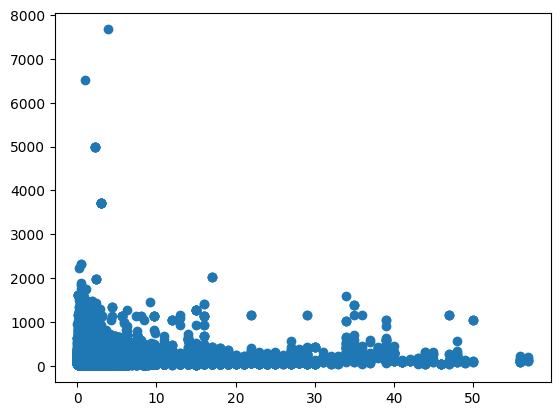

In [43]:
fig, ax = plt.subplots()
ax.scatter(hotels_europe_df_nnights1['distance'], hotels_europe_df_nnights1['price'])

The plot is a little bit crowded and it includes observations from all cities, all time periods, and for all types of accommodation.

This motivates the idea of conditioning on some variables (sometimes called `covariates`).

For example: What `price`-`distance` pattern do we see when we restrict our attention to three-star hotels in Paris that are considered as `Hotel`?

Let us create the equivalent figure with this restriction.

Let us first carry out the subsetting:

In [44]:
df = hotels_europe_df_nnights1.copy()
# There are pandas-type missing values for accommodation_type and such missing values they need to be handled separately
# We can first simply remove all observations with missing values for our conditioning variables.
# I.e. filter for non-missing:
df = df.loc[(df['stars'].notna()) & (df['city'].notna()) & (df['accommodation_type'].notna()),:]
# And then do the filtering by value:
df = df.loc[(df['stars'] == 3) & (df['city'] == 'Paris') & (df['accommodation_type'] == 'Hotel'),:]

And then proceed with the plotting:

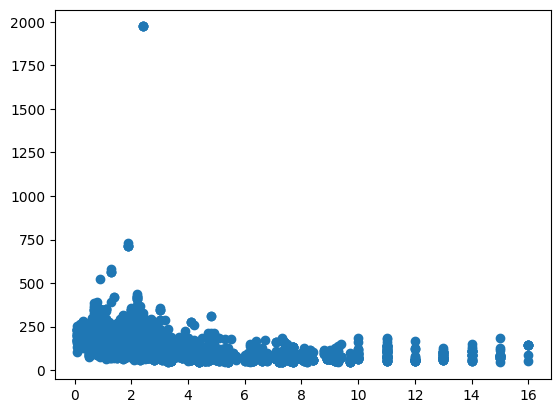

In [45]:
fig, ax = plt.subplots()
ax.scatter(df['distance'], df['price'])

I am not sure the pattern is cleaner (it does not necessarily need to be), but maybe the comparison makes more sense.